In [138]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "mymoviedb.csv",
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip"
)
df.columns = df.columns.str.lower().str.replace(" " , "_")
df.head()

,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   release_date       9837 non-null   str    
 1   title              9828 non-null   str    
 2   overview           9828 non-null   str    
 3   popularity         9827 non-null   float64
 4   vote_count         9827 non-null   str    
 5   vote_average       9827 non-null   str    
 6   original_language  9827 non-null   str    
 7   genre              9826 non-null   str    
 8   poster_url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [140]:
df.describe()

,popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [141]:
print(df.isna().sum())
df[df.isna().any(axis=1)]

release_date          0
title                 9
overview              9
popularity           10
vote_count           10
vote_average         10
original_language    10
genre                11
poster_url           11
dtype: int64


,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
1105,2013-10-20,Pixie Hollow Bake Off,Tink challenges Gelata to see who can bake the...,NaN,NaN,NaN,NaN,NaN,NaN
1106,- Just Desserts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1107,- If The Hue Fits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1108,- Dust Up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1109,- Scents And Sensibility,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1110,- Just One Of The Girls,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1111,- Volleybug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1112,- Hide And Tink,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1113,- Rainbow's Ends,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1114,- Fawn And Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [142]:
df = df.drop_duplicates()
df = df.dropna(how='any')

In [143]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['vote_count'] = df['vote_count'].astype("int")
df['vote_average']= df['vote_average'].astype("float")
df['popularity'] = df['popularity'].astype("float")
df['original_language'] = df['original_language'].astype('category')

In [144]:
df.info()

<class 'pandas.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   release_date       9826 non-null   datetime64[us]
 1   title              9826 non-null   str           
 2   overview           9826 non-null   str           
 3   popularity         9826 non-null   float64       
 4   vote_count         9826 non-null   int64         
 5   vote_average       9826 non-null   float64       
 6   original_language  9826 non-null   category      
 7   genre              9826 non-null   str           
 8   poster_url         9826 non-null   str           
dtypes: category(1), datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 700.8 KB


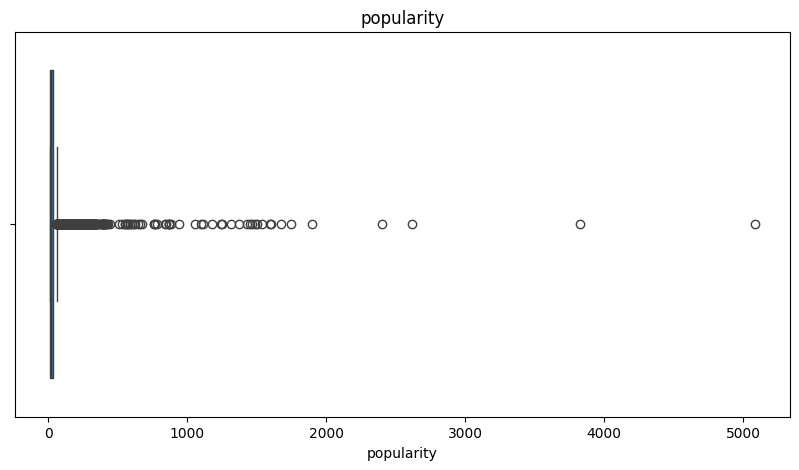

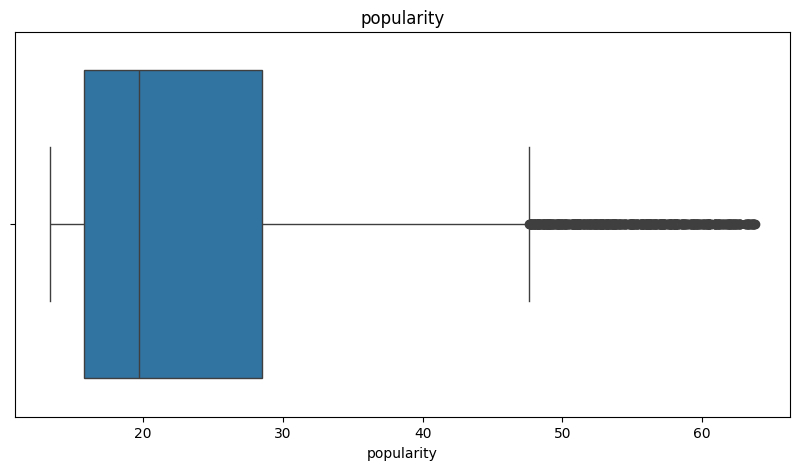

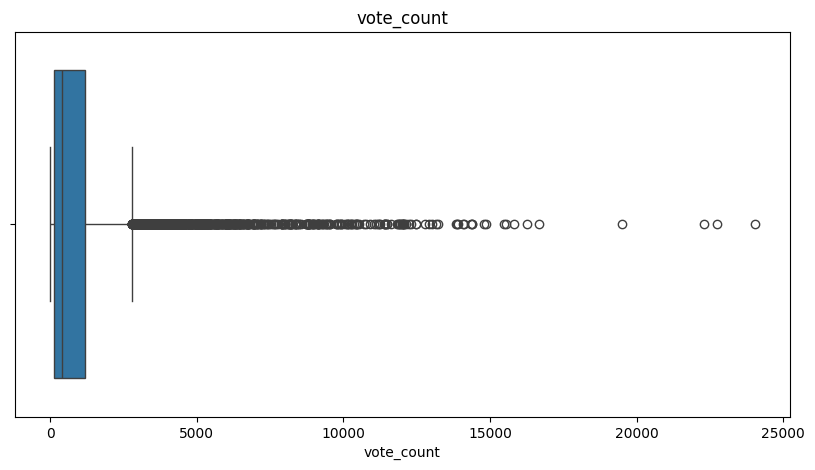

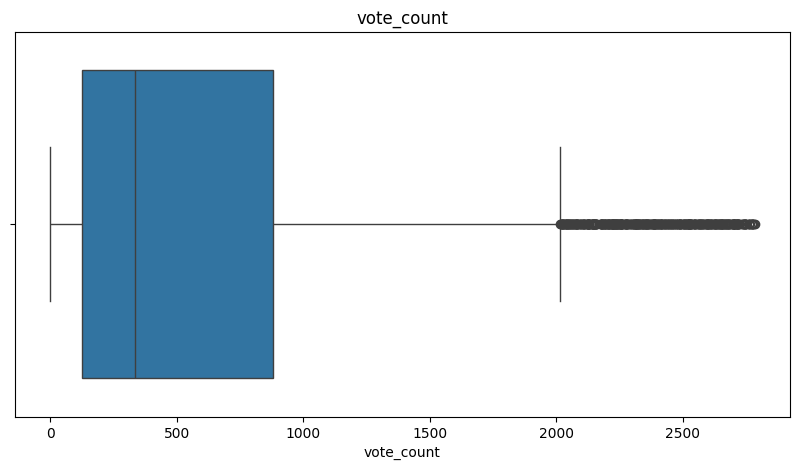

In [145]:
outliers = ['popularity', 'vote_count']
for col in outliers:
    plt.figure(figsize=(10 , 5))
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    plt.figure(figsize=(10 , 5))
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()


## Q1: What is the movie with the highest Popularity rate? And what kind is it?


In [146]:
highest_popualrity =df.loc[df['popularity'].idxmax(),['title']].values
genre = df.loc[df['popularity'].idxmax(),'genre']
print(f"The highest popularity rate is {highest_popualrity[0]} and is type {genre}")

The highest popularity rate is The Day Naruto Became Hokage and is type Comedy, Animation, Action, Adventure


## Q2: What year was the largest number of films produced?


   year  title
0  2018    454
1  2017    421
2  2021    413
3  2019    409
4  2016    374
5  2020    374
6  2015    318
7  2014    291
8  2013    265
9  2011    255


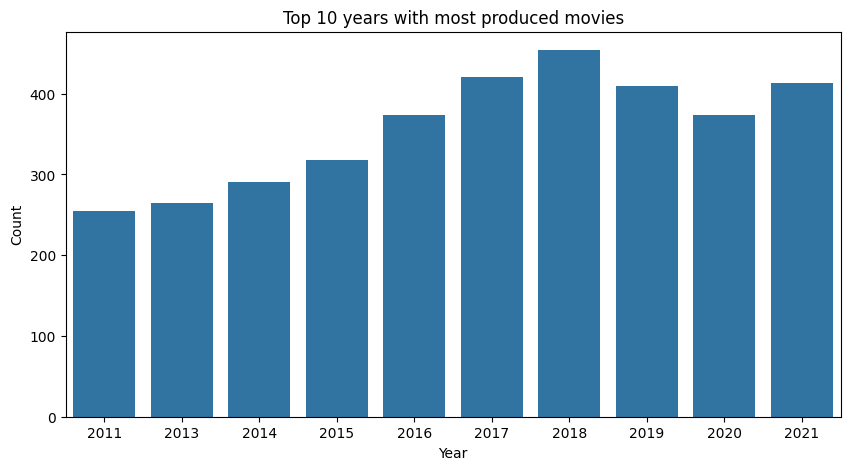

Text(0.5, 1.0, 'Top 10 years with most produced movies')

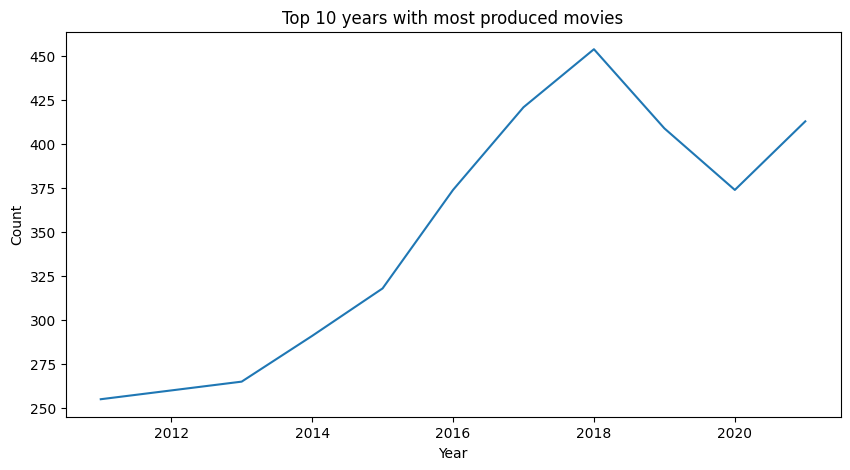

In [147]:
df['year'] = df['release_date'].dt.year

count_film = df.groupby("year")['title'].count().nlargest(10).reset_index()
print(count_film)
plt.figure(figsize=(10 , 5))
sns.barplot(data=count_film, x='year', y='title')
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Top 10 years with most produced movies")

plt.show()
plt.figure(figsize=(10 , 5))
sns.lineplot(data=count_film, x='year', y='title')
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Top 10 years with most produced movies")


## Q3: What is most of the film genre?


genre
Drama              3112
Comedy             2473
Action             2001
Thriller           1972
Adventure          1326
Romance            1226
Horror             1223
Animation          1116
Family             1097
Crime               979
Fantasy             936
Science Fiction     915
Mystery             598
History             366
War                 256
Music               254
Documentary         202
TV Movie            194
Western             110
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 10 Most Common Film Genres')

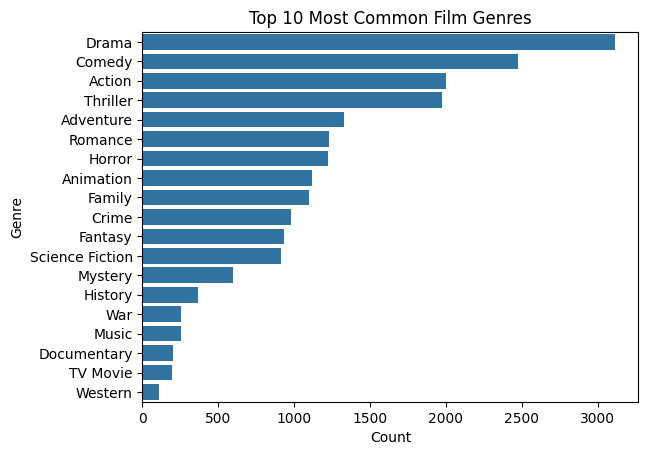

In [148]:
# len(df['genre'].unique())  # 2337  ???????

genre_counts = (df['genre'].str.split(',').explode().str.strip().value_counts())
print(genre_counts)

sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.xlabel("Count")
plt.ylabel("Genre")
plt.title("Top 10 Most Common Film Genres")

## Q4: What kind of movies take the highest rating? **

              genre  vote_average
0             Music      6.520482
1            Horror      6.419175
2             Crime      6.415616
3           Mystery      6.400000
4         Adventure      6.377258
5          TV Movie      6.374242
6          Thriller      6.360352
7       Documentary      6.355844
8             Drama      6.337773
9         Animation      6.327695
10          Romance      6.327163
11  Science Fiction      6.320379
12          Fantasy      6.317402
13          History      6.313333
14           Action      6.309753
15           Family      6.302165
16           Comedy      6.289474
17          Western      6.205714
18              War      6.106024


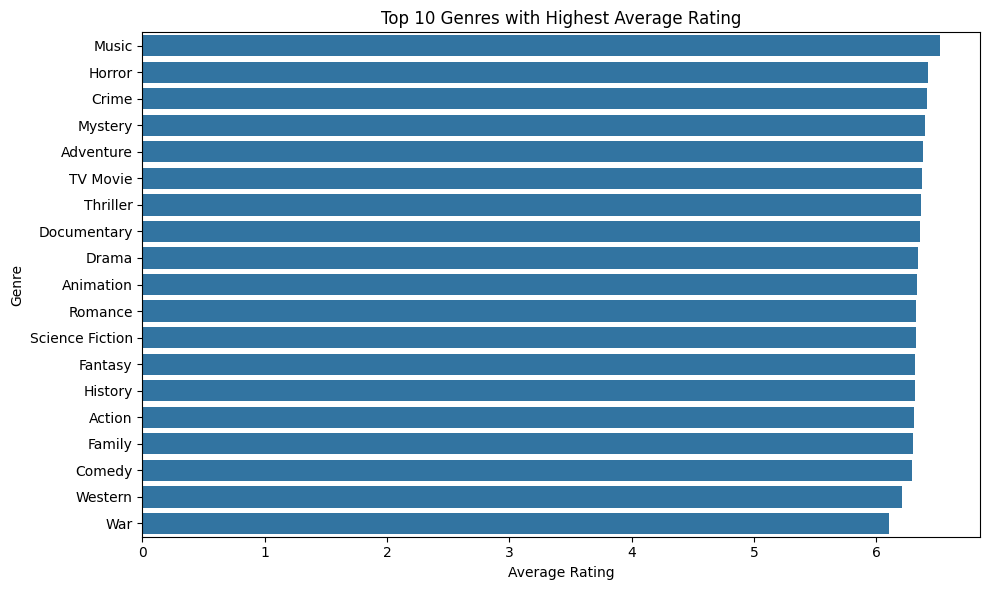

In [149]:
df_exploded = df.copy()
df_exploded['genre'] = df_exploded['genre'].str.split(',').explode('genre').str.strip()     # df ---> 7892 rows × 9 columns
                                                                                   # df_exploded ---> 20356 rows × 9 columns
genre_rating = df_exploded.groupby('genre')['vote_average'].mean().sort_values(ascending=False).reset_index()
print(genre_rating)
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_rating, x='vote_average', y='genre', order=genre_rating['genre'])
plt.xlabel("Average Rating" )
plt.ylabel("Genre")
plt.title("Top 10 Genres with Highest Average Rating")
plt.tight_layout()
plt.show()

In [150]:
df.columns

Index(['release_date', 'title', 'overview', 'popularity', 'vote_count',
       'vote_average', 'original_language', 'genre', 'poster_url', 'year'],
      dtype='str')

## Q5: Which movie is more popular? Which movie is less popular?


In [151]:
most_popular = df.loc[df['popularity'].idxmax(), ['title', 'popularity']]
least_popular = df.loc[df['popularity'].idxmin(), ['title', 'popularity']]

print(f"Most Popular Movie:{most_popular}")
print(f"Least Popular Movie: {least_popular}")

Most Popular Movie:title         The Day Naruto Became Hokage
popularity                          63.748
Name: 1047, dtype: object
Least Popular Movie: title         The United States vs. Billie Holiday
popularity                                  13.354
Name: 9835, dtype: object


## Q6: Which language produces the most movies?

  original_language  count
0                en   5869
1                ja    562
2                es    295
3                fr    270
4                ko    151
5                zh    116
6                it    112
7                cn    107
8                ru     78
9                de     77


Text(0.5, 1.0, 'Top 10 Languages with Most Movies')

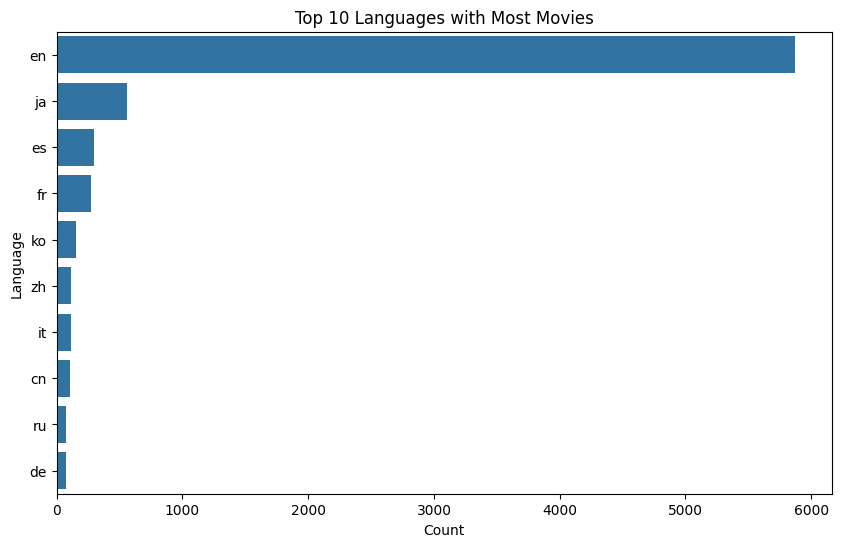

In [152]:
language_movie = df['original_language'].value_counts().head(10).reset_index()
print(language_movie)
plt.figure(figsize=(10, 6))
sns.barplot(data=language_movie, x='count', y='original_language', order=language_movie['original_language'])
plt.xlabel("Count")
plt.ylabel("Language")
plt.title("Top 10 Languages with Most Movies")

## Q:7 Is there a correlation between popularity and vote average?


<Axes: >

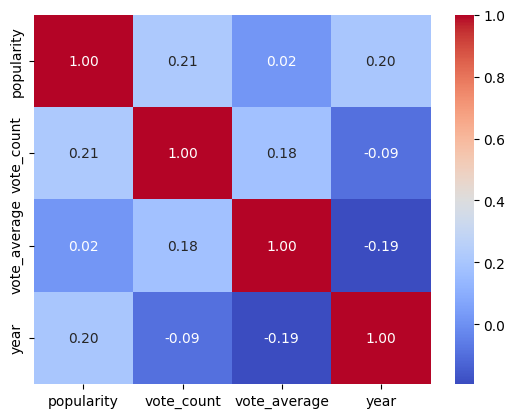

In [153]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f' ,cmap='coolwarm' )

## Q:8 How has the average movie rating changed over the years?


     year  vote_average
0    1902      8.000000
1    1920      8.000000
2    1921      8.050000
3    1922      7.650000
4    1925      7.700000
..    ...           ...
97   2020      6.587968
98   2021      6.450847
99   2022      2.462992
100  2023      0.000000
101  2024      0.000000

[102 rows x 2 columns]


Text(0.5, 1.0, 'Average Movie Rating Over the Years')

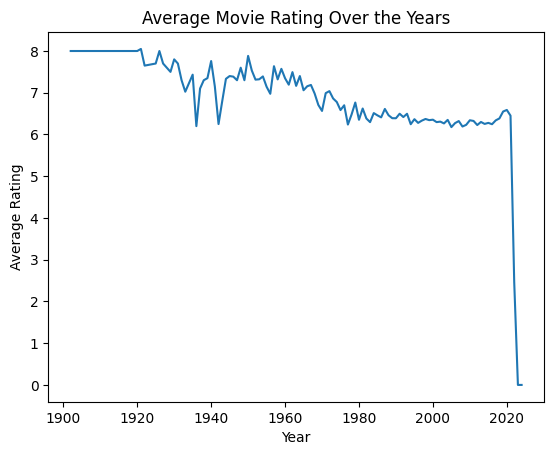

In [154]:
rating_years = df.groupby('year')['vote_average'].mean().reset_index()  # .loc[df['year'] > 2000]
print(rating_years)
sns.lineplot(data=rating_years, x='year', y='vote_average')
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating Over the Years")

## Q:9 Which languages produce the highest-rated movies on average?


  original_language  vote_average
0                ja      6.939146
1                ru      6.874359
2                zh      6.820690
3                de      6.722078
4                ko      6.720530
5                es      6.563390
6                cn      6.526168
7                it      6.450893
8                fr      6.279630
9                en      6.232510


Text(0.5, 1.0, 'Top 10 Languages by Average Rating')

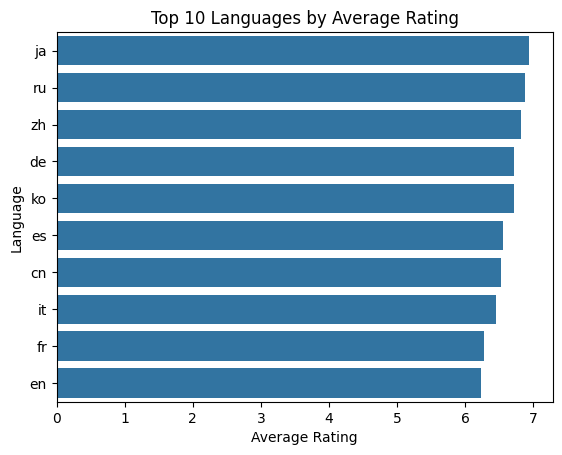

In [155]:
top_10_languages = language_movie['original_language'].tolist()
lan_rated = df[df['original_language'].isin(top_10_languages)]
lan_rated = lan_rated.groupby('original_language')['vote_average'].mean().sort_values(ascending=False).reset_index()

print(lan_rated)
sns.barplot(data = lan_rated , y = 'original_language' , x = 'vote_average', order = lan_rated['original_language'])
plt.xlabel("Average Rating")
plt.ylabel("Language")
plt.title("Top 10 Languages by Average Rating")

**